In [ ]:
# ==========================================
# Task 1.1 : Import Required Libraries
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("=" * 60)
print("LIBRARIES IMPORTED SUCCESSFULLY")
print("=" * 60)
print("TensorFlow :", tf.__version__)

LIBRARIES IMPORTED SUCCESSFULLY
TensorFlow : 2.20.0


In [ ]:
# ==========================================
# Task 1.2 : Load Fashion-MNIST Dataset
# ==========================================

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

print("=" * 60)
print("FASHION-MNIST DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print("\nTraining Images Shape :", train_images.shape)
print("Training Labels Shape :", train_labels.shape)

print("\nTesting Images Shape  :", test_images.shape)
print("Testing Labels Shape  :", test_labels.shape)

print("\nImage Size :", train_images.shape[1], "x", train_images.shape[2])
print("Number of Classes :", len(np.unique(train_labels)))
print("Class Labels :", np.unique(train_labels))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
FASHION-MNIST DATASET LOADED SUCCESSFULLY

Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)

Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)

Image Size : 28 x 28
Number of Classes : 10
Class Labels : [0 1 2 3 4 5 6 7 8 9]


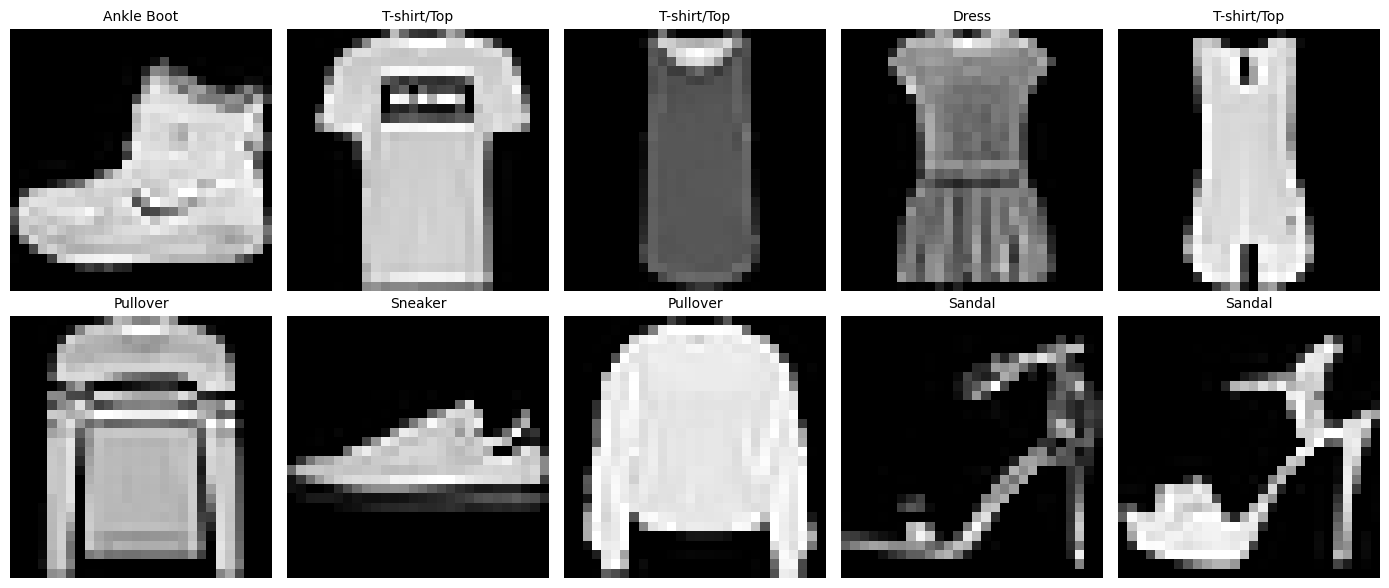

In [ ]:
# ==========================================
# Task 1.3 : Display Sample Images
# ==========================================

class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

plt.figure(figsize=(14,6))

for index in range(10):
    plt.subplot(2,5,index+1)
    plt.imshow(train_images[index], cmap="gray")
    plt.title(class_names[train_labels[index]], fontsize=10)
    plt.axis("off")

plt.tight_layout()

plt.savefig("plot1.png", dpi=300, bbox_inches="tight")

plt.show()

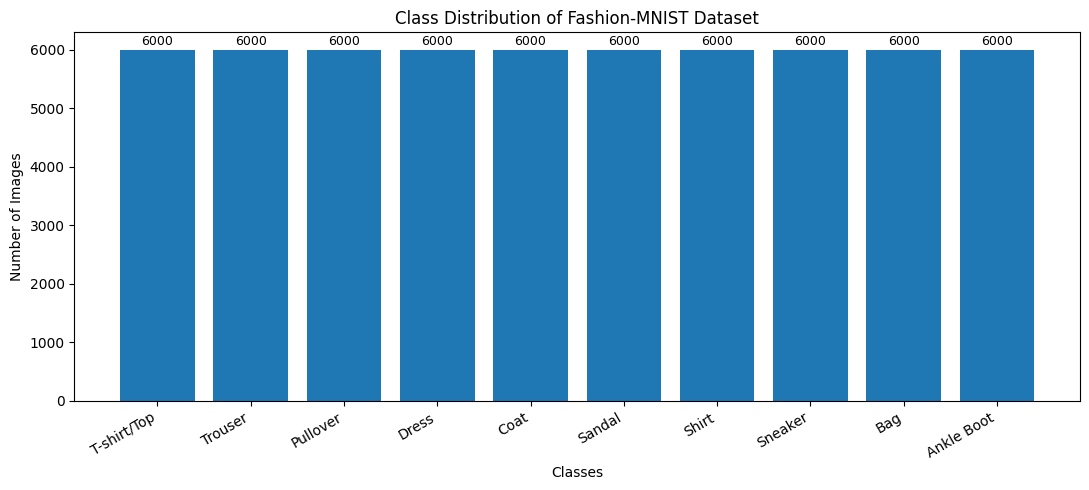

In [ ]:
# ==========================================
# Task 1.4 : Class Distribution
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

class_count = np.bincount(train_labels)

plt.figure(figsize=(11,5))

bars = plt.bar(class_names, class_count)

plt.title("Class Distribution of Fashion-MNIST Dataset")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=30, ha="right")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+80,
        str(int(bar.get_height())),
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig("plot2.png", dpi=300)

plt.show()

In [ ]:
# ==========================================
# Task 2.1 : Data Preprocessing
# ==========================================

print("="*60)
print("BEFORE PREPROCESSING")
print("="*60)

print("Training Images :", train_images.shape)
print("Testing Images  :", test_images.shape)

print("Training Labels :", train_labels.shape)
print("Testing Labels  :", test_labels.shape)

# Flatten Images

train_flat = train_images.reshape(train_images.shape[0], 784)
test_flat = test_images.reshape(test_images.shape[0], 784)

# Normalize

train_flat = train_flat.astype("float32") / 255.0
test_flat = test_flat.astype("float32") / 255.0

# One-Hot Encoding

train_encoded = to_categorical(train_labels, num_classes=10)
test_encoded = to_categorical(test_labels, num_classes=10)

print("\n"+"="*60)
print("AFTER PREPROCESSING")
print("="*60)

print("Flattened Training :", train_flat.shape)
print("Flattened Testing  :", test_flat.shape)

print("\nEncoded Training :", train_encoded.shape)
print("Encoded Testing  :", test_encoded.shape)

print("\nFirst Five Normalized Samples")

print(pd.DataFrame(train_flat[:5, :10]))

print("\nFirst Five Encoded Labels")

print(pd.DataFrame(train_encoded[:5]))

BEFORE PREPROCESSING
Training Images : (60000, 28, 28)
Testing Images  : (10000, 28, 28)
Training Labels : (60000,)
Testing Labels  : (10000,)

AFTER PREPROCESSING
Flattened Training : (60000, 784)
Flattened Testing  : (10000, 784)

Encoded Training : (60000, 10)
Encoded Testing  : (10000, 10)

First Five Normalized Samples
     0    1    2    3    4         5    6    7         8         9
0  0.0  0.0  0.0  0.0  0.0  0.000000  0.0  0.0  0.000000  0.000000
1  0.0  0.0  0.0  0.0  0.0  0.003922  0.0  0.0  0.000000  0.000000
2  0.0  0.0  0.0  0.0  0.0  0.000000  0.0  0.0  0.000000  0.086275
3  0.0  0.0  0.0  0.0  0.0  0.000000  0.0  0.0  0.129412  0.376471
4  0.0  0.0  0.0  0.0  0.0  0.000000  0.0  0.0  0.000000  0.000000

First Five Encoded Labels
     0    1    2    3    4    5    6    7    8    9
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0
1  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
2  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
3  0.0  0.0  0.0  1.0  0.0  0.0  0.0 

In [ ]:
# ==========================================
# Task 3 : Model Construction
# ==========================================

baseline_mlp = Sequential(

    [

        Input(shape=(784,), name="Input_Layer"),

        Dense(
            128,
            activation="relu",
            name="Hidden_Layer_1"
        ),

        Dense(
            64,
            activation="relu",
            name="Hidden_Layer_2"
        ),

        Dense(
            10,
            activation="softmax",
            name="Output_Layer"
        )

    ]

)

baseline_mlp.compile(

    optimizer=Adam(),

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

print("="*60)
print("BASELINE MLP MODEL CREATED SUCCESSFULLY")
print("="*60)

baseline_mlp.summary()

BASELINE MLP MODEL CREATED SUCCESSFULLY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==========================================
# Task 4 : Model Training
# ==========================================

import time

training_start = time.time()

baseline_history = baseline_mlp.fit(

    train_flat,

    train_encoded,

    validation_split=0.20,

    epochs=20,

    batch_size=32,

    verbose=1

)

training_end = time.time()

baseline_training_time = training_end - training_start

print("\n" + "="*60)
print("BASELINE MODEL TRAINING COMPLETED")
print("="*60)

print(f"Training Time : {baseline_training_time:.2f} seconds")

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8212 - loss: 0.5103 - val_accuracy: 0.8503 - val_loss: 0.4209
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8613 - loss: 0.3821 - val_accuracy: 0.8641 - val_loss: 0.3763
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8739 - loss: 0.3403 - val_accuracy: 0.8748 - val_loss: 0.3410
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8827 - loss: 0.3154 - val_accuracy: 0.8786 - val_loss: 0.3518
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8902 - loss: 0.2961 - val_accuracy: 0.8830 - val_loss: 0.3312
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8954 - loss: 0.2793 - val_accuracy: 0.8825 - val_loss: 0.3245
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8980 - loss: 0.2686 - val_accuracy: 0.8805 - val_loss: 0.3359
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9041 - loss: 0.2570 - 

BASELINE MODEL PERFORMANCE
Accuracy  : 0.8809
Precision : 0.8820
Recall    : 0.8809
F1-Score  : 0.8802

Classification Report

              precision    recall  f1-score   support

 T-shirt/Top       0.85      0.83      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.80      0.78      0.79      1000
       Dress       0.87      0.91      0.89      1000
        Coat       0.73      0.85      0.79      1000
      Sandal       0.99      0.93      0.96      1000
       Shirt       0.76      0.64      0.69      1000
     Sneaker       0.93      0.95      0.94      1000
         Bag       0.97      0.97      0.97      1000
  Ankle Boot       0.93      0.97      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



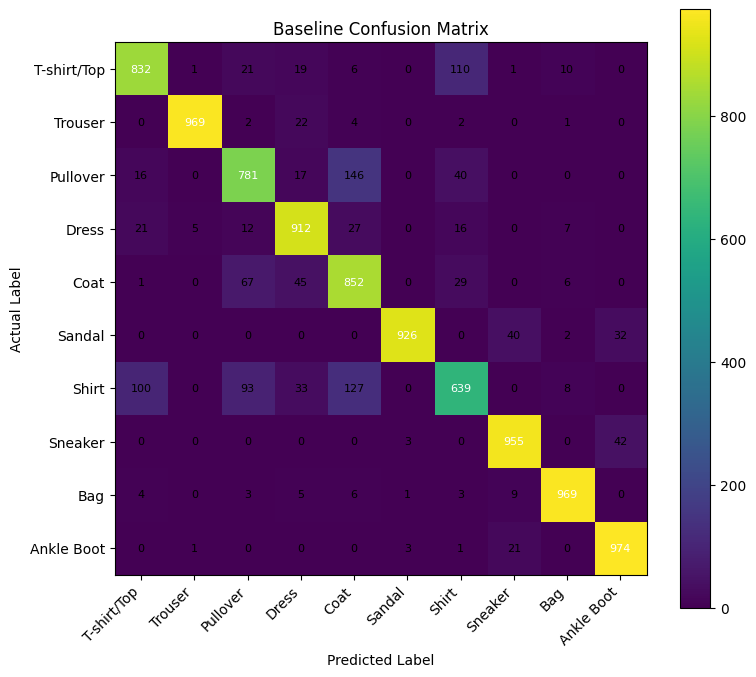

In [ ]:
# ==========================================
# Task 5 : Model Evaluation
# ==========================================

baseline_probabilities = baseline_mlp.predict(test_flat, verbose=0)

baseline_predictions = np.argmax(baseline_probabilities, axis=1)

baseline_actual = np.argmax(test_encoded, axis=1)

baseline_accuracy = accuracy_score(
    baseline_actual,
    baseline_predictions
)

baseline_precision = precision_score(
    baseline_actual,
    baseline_predictions,
    average="weighted"
)

baseline_recall = recall_score(
    baseline_actual,
    baseline_predictions,
    average="weighted"
)

baseline_f1 = f1_score(
    baseline_actual,
    baseline_predictions,
    average="weighted"
)

print("="*60)
print("BASELINE MODEL PERFORMANCE")
print("="*60)

print(f"Accuracy  : {baseline_accuracy:.4f}")
print(f"Precision : {baseline_precision:.4f}")
print(f"Recall    : {baseline_recall:.4f}")
print(f"F1-Score  : {baseline_f1:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        baseline_actual,
        baseline_predictions,
        target_names=class_names
    )
)

baseline_confusion = confusion_matrix(
    baseline_actual,
    baseline_predictions
)

plt.figure(figsize=(8,7))

plt.imshow(baseline_confusion)

plt.title("Baseline Confusion Matrix")

plt.colorbar()

plt.xticks(
    np.arange(10),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(10),
    class_names
)

for row in range(10):
    for col in range(10):

        plt.text(
            col,
            row,
            baseline_confusion[row, col],
            ha="center",
            va="center",
            color="white"
            if baseline_confusion[row, col] >
            baseline_confusion.max()/2
            else "black",
            fontsize=8
        )

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()

plt.savefig("plot3.png", dpi=300)

plt.show()

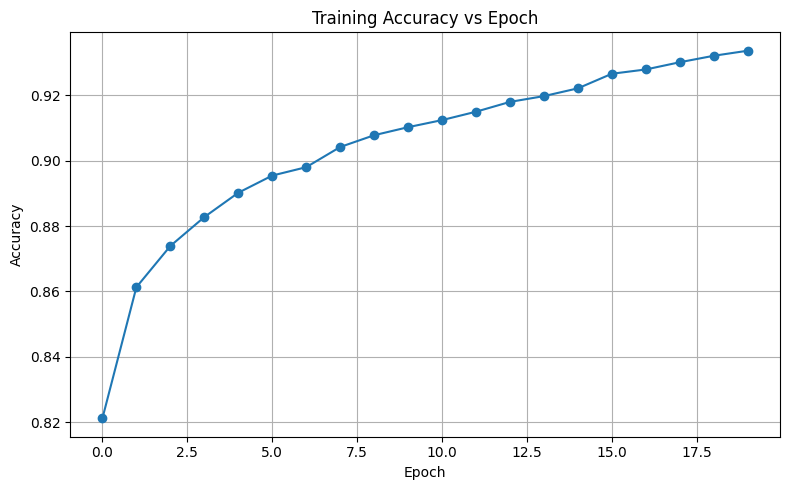

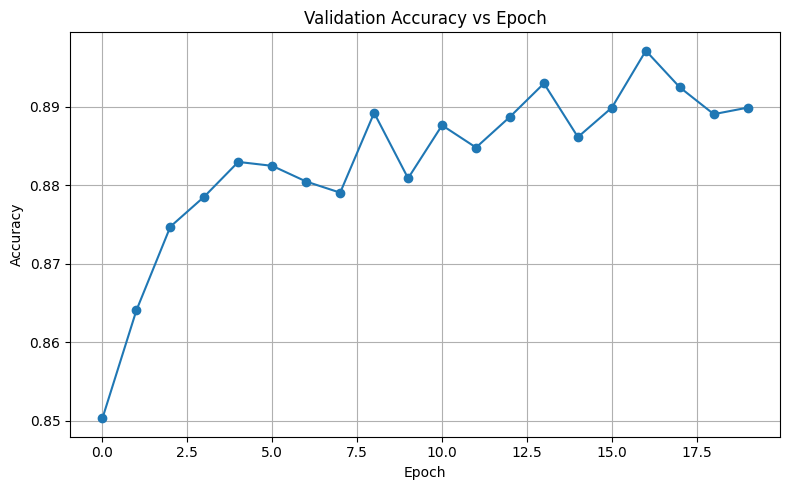

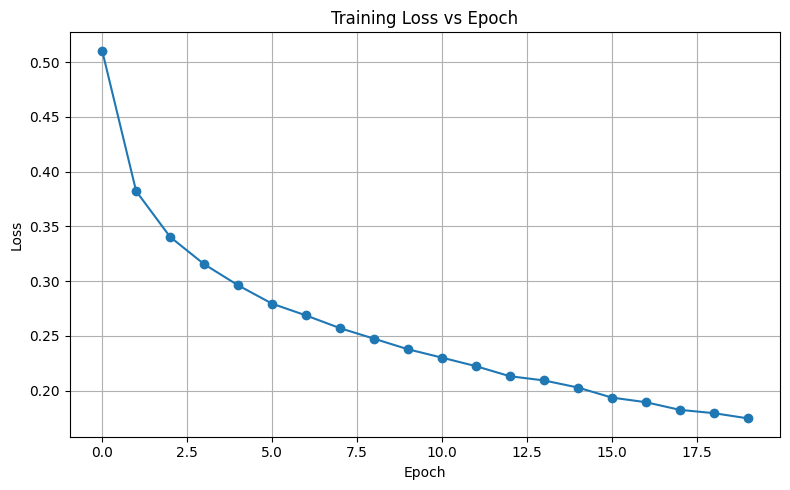

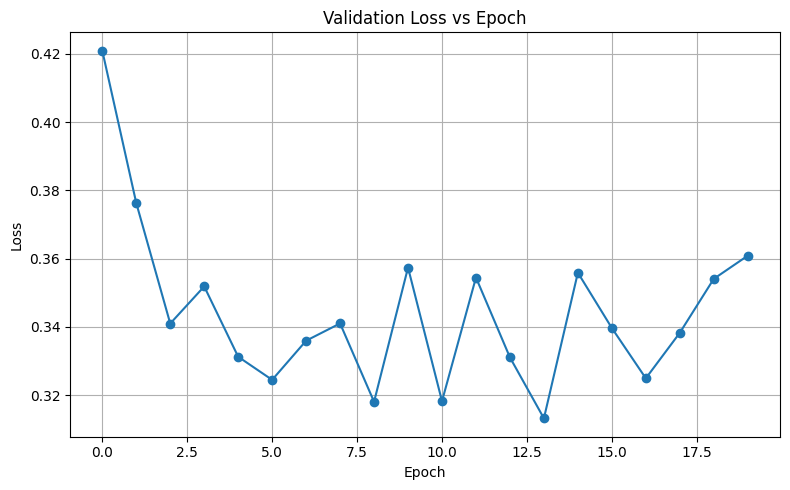

In [ ]:
# ==========================================
# Task 5.1 : Training History Plots
# ==========================================

# Training Accuracy
plt.figure(figsize=(8,5))
plt.plot(baseline_history.history["accuracy"], marker="o")
plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.tight_layout()
plt.savefig("plot4.png", dpi=300)
plt.show()

# Validation Accuracy
plt.figure(figsize=(8,5))
plt.plot(baseline_history.history["val_accuracy"], marker="o")
plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.tight_layout()
plt.savefig("plot5.png", dpi=300)
plt.show()

# Training Loss
plt.figure(figsize=(8,5))
plt.plot(baseline_history.history["loss"], marker="o")
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig("plot6.png", dpi=300)
plt.show()

# Validation Loss
plt.figure(figsize=(8,5))
plt.plot(baseline_history.history["val_loss"], marker="o")
plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig("plot7.png", dpi=300)
plt.show()

In [ ]:
# ==========================================
# Task 6 : Hyperparameter Optimization
# ==========================================

import time
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV

# -------------------------------------------------------
# Model Builder
# -------------------------------------------------------

def build_mlp(
    hidden_layers=2,
    hidden_neurons=128,
    learning_rate=0.001,
    optimizer="adam",
    activation="relu",
    dropout_rate=0.0
):

    model = Sequential()

    model.add(Input(shape=(784,)))

    for _ in range(hidden_layers):

        model.add(
            Dense(
                hidden_neurons,
                activation=activation
            )
        )

        if dropout_rate > 0:

            model.add(
                Dropout(dropout_rate)
            )

    model.add(
        Dense(
            10,
            activation="softmax"
        )
    )

    if optimizer == "adam":

        opt = Adam(
            learning_rate=learning_rate
        )

    elif optimizer == "sgd":

        opt = SGD(
            learning_rate=learning_rate
        )

    else:

        opt = RMSprop(
            learning_rate=learning_rate
        )

    model.compile(

        optimizer=opt,

        loss="categorical_crossentropy",

        metrics=["accuracy"]

    )

    return model

# -------------------------------------------------------
# SciKeras Wrapper
# -------------------------------------------------------

keras_classifier = KerasClassifier(

    model=build_mlp,

    verbose=0

)

# -------------------------------------------------------
# Search Space
# -------------------------------------------------------

parameter_grid = {

    "model__hidden_layers":[1,2,3],

    "model__hidden_neurons":[32,64,128,256],

    "model__learning_rate":[0.1,0.01,0.001],

    "model__optimizer":[
        "adam",
        "sgd",
        "rmsprop"
    ],

    "model__activation":[
        "relu",
        "tanh",
        "sigmoid"
    ],

    "model__dropout_rate":[
        0.0,
        0.2,
        0.5
    ],

    "batch_size":[
        16,
        32,
        64,
        128
    ],

    "epochs":[
        10,
        20,
        30
    ]

}

# -------------------------------------------------------
# Random Search
# -------------------------------------------------------

random_search = RandomizedSearchCV(

    estimator=keras_classifier,

    param_distributions=parameter_grid,

    n_iter=15,

    cv=5,

    scoring="accuracy",

    random_state=42,

    verbose=2,

    n_jobs=1

)

print("="*60)
print("STARTING HYPERPARAMETER OPTIMIZATION")
print("="*60)

start_time = time.time()

random_search.fit(
    train_flat,
    train_encoded
)

end_time = time.time()

print("\n"+"="*60)
print("OPTIMIZATION COMPLETED")
print("="*60)

print("\nBest Parameters\n")

for key,value in random_search.best_params_.items():

    print(f"{key:30} : {value}")

print("\nBest Cross Validation Accuracy")

print(random_search.best_score_)

print("\nOptimization Time")

print(f"{end_time-start_time:.2f} seconds")

STARTING HYPERPARAMETER OPTIMIZATION
Fitting 5 folds for each of 15 candidates, totalling 75 fits
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer=sgd; total time=  39.3s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer=sgd; total time=  38.4s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer=sgd; total time=  39.7s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer=sgd; total time=  40.4s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, mo

OPTIMIZED MLP MODEL CREATED SUCCESSFULLY


Model: "sequential_77"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_98 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_99 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_3 (Dense)          │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_100 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,794 (526.54 KB)

 Trainable params: 134,794 (526.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.7876 - loss: 0.5844 - val_accuracy: 0.8298 - val_loss: 0.4638
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8358 - loss: 0.4531 - val_accuracy: 0.8418 - val_loss: 0.4352
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8501 - loss: 0.4174 - val_accuracy: 0.8662 - val_loss: 0.3703
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8571 - loss: 0.3978 - val_accuracy: 0.8665 - val_loss: 0.3693
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8652 - loss: 0.3780 - val_accuracy: 0.8606 - val_loss: 0.3893
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8691 - loss: 0.3661 - val_accuracy: 0.8738 - val_loss: 0.3514
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8721 - loss: 0.3548 - val_accuracy: 0.8722 - val_loss: 0.3590
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8746 - loss: 0.3499 -

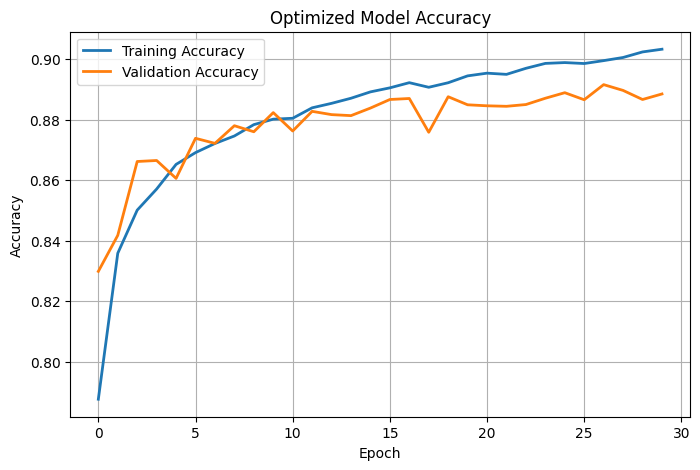

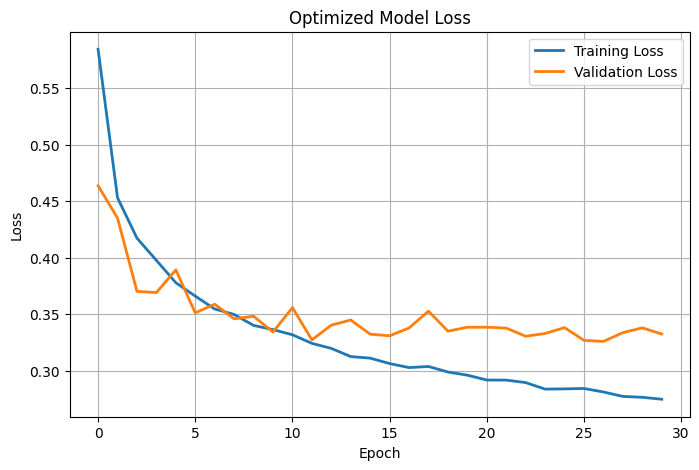

In [ ]:
# ==========================================
# Task 6.3 : Train Optimized MLP Model
# ==========================================

import time
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import RMSprop

# -----------------------------------------------------
# Build Optimized Model
# -----------------------------------------------------

optimized_model = Sequential()

optimized_model.add(Input(shape=(784,)))

optimized_model.add(Dense(
    128,
    activation="tanh",
    name="Hidden_Layer_1"
))
optimized_model.add(Dropout(0.2))

optimized_model.add(Dense(
    128,
    activation="tanh",
    name="Hidden_Layer_2"
))
optimized_model.add(Dropout(0.2))

optimized_model.add(Dense(
    128,
    activation="tanh",
    name="Hidden_Layer_3"
))
optimized_model.add(Dropout(0.2))

optimized_model.add(Dense(
    10,
    activation="softmax",
    name="Output_Layer"
))

optimized_model.compile(
    optimizer=RMSprop(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("="*60)
print("OPTIMIZED MLP MODEL CREATED SUCCESSFULLY")
print("="*60)

optimized_model.summary()

# -----------------------------------------------------
# Train Model
# -----------------------------------------------------

training_start = time.time()

optimized_history = optimized_model.fit(

    train_flat,
    train_encoded,

    validation_split=0.20,

    epochs=30,

    batch_size=32,

    verbose=1

)

training_end = time.time()

print("\n")
print("="*60)
print("OPTIMIZED MODEL TRAINING COMPLETED")
print("="*60)

print(f"Training Time : {training_end-training_start:.2f} seconds")

# -----------------------------------------------------
# Accuracy Curve
# -----------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    optimized_history.history["accuracy"],
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    optimized_history.history["val_accuracy"],
    linewidth=2,
    label="Validation Accuracy"
)

plt.title("Optimized Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(
    "optimized_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# -----------------------------------------------------
# Loss Curve
# -----------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    optimized_history.history["loss"],
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    optimized_history.history["val_loss"],
    linewidth=2,
    label="Validation Loss"
)

plt.title("Optimized Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig(
    "optimized_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
OPTIMIZED MODEL PERFORMANCE
Accuracy  : 0.8805
Precision : 0.8818
Recall    : 0.8805
F1-Score  : 0.8810

Classification Report

              precision    recall  f1-score   support

 T-shirt/Top       0.85      0.83      0.84      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.77      0.81      0.79      1000
       Dress       0.89      0.89      0.89      1000
        Coat       0.80      0.78      0.79      1000
      Sandal       0.97      0.95      0.96      1000
       Shirt       0.69      0.71      0.70      1000
     Sneaker       0.94      0.95      0.94      1000
         Bag       0.97      0.97      0.97      1000
  Ankle Boot       0.95      0.96      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



<Figure size 1000x800 with 0 Axes>

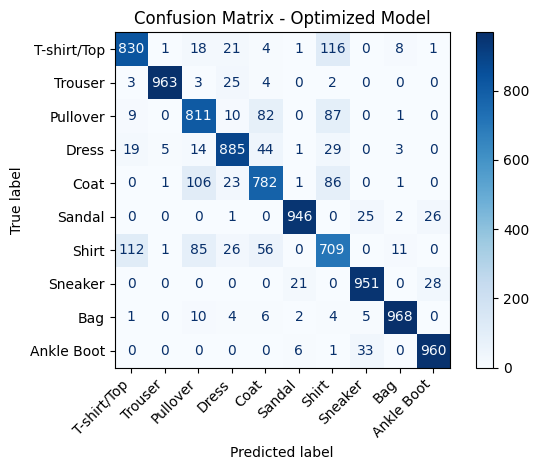



      Metric  Optimized Model
0   Accuracy         0.880500
1  Precision         0.881804
2     Recall         0.880500
3   F1 Score         0.881022


In [ ]:
# ==========================================
# Task 6.4 : Evaluation of Optimized Model
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# -----------------------------------------------------
# Predictions
# -----------------------------------------------------

prediction_probability = optimized_model.predict(test_flat)

predicted_labels = np.argmax(
    prediction_probability,
    axis=1
)

true_labels = np.argmax(
    test_encoded,
    axis=1
)

# -----------------------------------------------------
# Performance Metrics
# -----------------------------------------------------

optimized_accuracy = accuracy_score(
    true_labels,
    predicted_labels
)

optimized_precision = precision_score(
    true_labels,
    predicted_labels,
    average="weighted"
)

optimized_recall = recall_score(
    true_labels,
    predicted_labels,
    average="weighted"
)

optimized_f1 = f1_score(
    true_labels,
    predicted_labels,
    average="weighted"
)

print("="*60)
print("OPTIMIZED MODEL PERFORMANCE")
print("="*60)

print(f"Accuracy  : {optimized_accuracy:.4f}")
print(f"Precision : {optimized_precision:.4f}")
print(f"Recall    : {optimized_recall:.4f}")
print(f"F1-Score  : {optimized_f1:.4f}")

# -----------------------------------------------------
# Classification Report
# -----------------------------------------------------

class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

print("\nClassification Report\n")

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names
    )
)

# -----------------------------------------------------
# Confusion Matrix
# -----------------------------------------------------

conf_matrix = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(figsize=(10,8))

display = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=class_names
)

display.plot(
    cmap="Blues",
    values_format="d"
)

plt.xticks(rotation=45, ha="right")

plt.title("Confusion Matrix - Optimized Model")

plt.tight_layout()

plt.savefig(
    "optimized_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# -----------------------------------------------------
# Store Results
# -----------------------------------------------------

optimized_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Optimized Model":[
        optimized_accuracy,
        optimized_precision,
        optimized_recall,
        optimized_f1
    ]

})

print("\n")
print(optimized_results)